In [68]:
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
warnings.filterwarnings('ignore')

##1. Load and Explore the Dataset

In [3]:
df = pd.read_csv('/content/drive/MyDrive/Datasets/CarPrice_Assignment (1).csv')

In [4]:
print("== First 5 records ==")
df.head()

== First 5 records ==


,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [5]:
df.sample(10)

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
64,65,0,mazda 626,gas,std,four,hatchback,fwd,front,98.8,...,122,2bbl,3.39,3.39,8.6,84,4800,26,32,11245.0
25,26,1,dodge colt hardtop,gas,std,four,sedan,fwd,front,93.7,...,90,2bbl,2.97,3.23,9.4,68,5500,31,38,6692.0
109,110,0,peugeot 504 (sw),gas,std,four,wagon,rwd,front,114.2,...,120,mpfi,3.46,3.19,8.4,97,5000,19,24,12440.0
108,109,0,peugeot 304,diesel,turbo,four,sedan,rwd,front,107.9,...,152,idi,3.70,3.52,21.0,95,4150,28,33,13200.0
202,203,-1,volvo 244dl,gas,std,four,sedan,rwd,front,109.1,...,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485.0
86,87,1,mitsubishi pajero,gas,std,four,sedan,fwd,front,96.3,...,122,2bbl,3.35,3.46,8.5,88,5000,25,32,8189.0
162,163,0,toyota mark ii,gas,std,four,sedan,fwd,front,95.7,...,98,2bbl,3.19,3.03,9.0,70,4800,28,34,9258.0
79,80,1,mitsubishi g4,gas,turbo,two,hatchback,fwd,front,93.0,...,98,spdi,3.03,3.39,7.6,102,5500,24,30,7689.0
99,100,0,nissan rogue,gas,std,four,hatchback,fwd,front,97.2,...,120,2bbl,3.33,3.47,8.5,97,5200,27,34,8949.0
117,118,0,peugeot 604sl,gas,turbo,four,sedan,rwd,front,108.0,...,134,mpfi,3.61,3.21,7.0,142,5600,18,24,18150.0


In [6]:
print("== No of Rows and Columns ==\n")
df.shape

== No of Rows and Columns ==



(205, 26)

In [7]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

In [8]:
print("== Duplicate Records ==\n")
print(df.duplicated().sum())

== Duplicate Records ==

0


In [9]:
print("== Null values ==\n")
df.isna().sum()

== Null values ==



,0
car_ID,0
symboling,0
CarName,0
fueltype,0
aspiration,0
doornumber,0
carbody,0
drivewheel,0
enginelocation,0
wheelbase,0


In [10]:
print("== Statistical Information ==\n")
df.describe()

== Statistical Information ==



,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,103.000000,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,59.322565,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,1.000000,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,52.000000,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,103.000000,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,154.000000,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,205.000000,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


##2. Data Preprocessing

In [11]:
df_corr = df.corr(numeric_only=True)
df_corr

,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
car_ID,1.000000,-0.151621,0.129729,0.170636,0.052387,0.255960,0.071962,-0.033930,0.260064,-0.160824,0.150276,-0.015006,-0.203789,0.015940,0.011255,-0.109093
symboling,-0.151621,1.000000,-0.531954,-0.357612,-0.232919,-0.541038,-0.227691,-0.105790,-0.130051,-0.008735,-0.178515,0.070873,0.273606,-0.035823,0.034606,-0.079978
wheelbase,0.129729,-0.531954,1.000000,0.874587,0.795144,0.589435,0.776386,0.569329,0.488750,0.160959,0.249786,0.353294,-0.360469,-0.470414,-0.544082,0.577816
carlength,0.170636,-0.357612,0.874587,1.000000,0.841118,0.491029,0.877728,0.683360,0.606454,0.129533,0.158414,0.552623,-0.287242,-0.670909,-0.704662,0.682920
carwidth,0.052387,-0.232919,0.795144,0.841118,1.000000,0.279210,0.867032,0.735433,0.559150,0.182942,0.181129,0.640732,-0.220012,-0.642704,-0.677218,0.759325
carheight,0.255960,-0.541038,0.589435,0.491029,0.279210,1.000000,0.295572,0.067149,0.171071,-0.055307,0.261214,-0.108802,-0.320411,-0.048640,-0.107358,0.119336
curbweight,0.071962,-0.227691,0.776386,0.877728,0.867032,0.295572,1.000000,0.850594,0.648480,0.168790,0.151362,0.750739,-0.266243,-0.757414,-0.797465,0.835305
enginesize,-0.033930,-0.105790,0.569329,0.683360,0.735433,0.067149,0.850594,1.000000,0.583774,0.203129,0.028971,0.809769,-0.244660,-0.653658,-0.677470,0.874145
boreratio,0.260064,-0.130051,0.488750,0.606454,0.559150,0.171071,0.648480,0.583774,1.000000,-0.055909,0.005197,0.573677,-0.254976,-0.584532,-0.587012,0.553173
stroke,-0.160824,-0.008735,0.160959,0.129533,0.182942,-0.055307,0.168790,0.203129,-0.055909,1.000000,0.186110,0.080940,-0.067964,-0.042145,-0.043931,0.079443


In [12]:
df = df.drop(columns=['car_ID'])
df

,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,168.8,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,168.8,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,171.2,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,176.6,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,176.6,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,-1,volvo 145e (sw),gas,std,four,sedan,rwd,front,109.1,188.8,...,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845.0
201,-1,volvo 144ea,gas,turbo,four,sedan,rwd,front,109.1,188.8,...,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045.0
202,-1,volvo 244dl,gas,std,four,sedan,rwd,front,109.1,188.8,...,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485.0
203,-1,volvo 246,diesel,turbo,four,sedan,rwd,front,109.1,188.8,...,145,idi,3.01,3.40,23.0,106,4800,26,27,22470.0


In [13]:
df['enginetype'].value_counts()

,count
enginetype,
ohc,148
ohcf,15
ohcv,13
dohc,12
l,12
rotor,4
dohcv,1


In [14]:
df['fuelsystem'].value_counts()

,count
fuelsystem,
mpfi,94
2bbl,66
idi,20
1bbl,11
spdi,9
4bbl,3
mfi,1
spfi,1


In [30]:
# df['cylindernumber'] = df['cylindernumber'].str.lower().str.strip()

# cylinder_dict = {
#     'two':2,
#     'three':3,
#     'four':4,
#     'five':5,
#     'six':6,
#     'eight':8,
#     'twelve':12
# }

# df['cylindernumber'] = df['cylindernumber'].map(cylinder_dict)

In [31]:
df['cylindernumber'].isna().sum()

np.int64(0)

In [32]:
categorical = [
    'fueltype',
    'aspiration',
    'carbody',
    'drivewheel',
    'enginetype',
    'enginelocation',
    'doornumber',
    'fuelsystem'
]

df_encoded = pd.get_dummies(
    df,
    columns=categorical,
    drop_first=True,
    dtype=int
)

df_encoded.sample(20)

,symboling,CarName,wheelbase,carlength,carwidth,carheight,curbweight,cylindernumber,enginesize,boreratio,...,enginetype_rotor,enginelocation_rear,doornumber_two,fuelsystem_2bbl,fuelsystem_4bbl,fuelsystem_idi,fuelsystem_mfi,fuelsystem_mpfi,fuelsystem_spdi,fuelsystem_spfi
4,2,audi 100ls,99.4,176.6,66.4,54.3,2824,5,136,3.19,...,0,0,0,0,0,0,0,1,0,0
119,1,plymouth cricket,93.7,157.3,63.8,50.8,2128,4,98,3.03,...,0,0,1,0,0,0,0,0,1,0
89,1,Nissan versa,94.5,165.3,63.8,54.5,1889,4,97,3.15,...,0,0,1,1,0,0,0,0,0,0
133,2,saab 99le,99.1,186.6,66.5,56.1,2695,4,121,3.54,...,0,0,0,0,0,0,0,1,0,0
188,2,volkswagen dasher,97.3,171.7,65.5,55.7,2300,4,109,3.19,...,0,0,0,0,0,0,0,1,0,0
14,1,bmw z4,103.5,189.0,66.9,55.7,3055,6,164,3.31,...,0,0,0,0,0,0,0,1,0,0
161,0,toyota corolla,95.7,166.3,64.4,52.8,2122,4,98,3.19,...,0,0,0,1,0,0,0,0,0,0
57,3,mazda rx-7 gs,95.3,169.0,65.7,49.6,2385,2,70,3.33,...,1,0,1,0,1,0,0,0,0,0
174,-1,toyota celica gt,102.4,175.6,66.5,54.9,2480,4,110,3.27,...,0,0,0,0,0,1,0,0,0,0
2,1,alfa-romero Quadrifoglio,94.5,171.2,65.5,52.4,2823,6,152,2.68,...,0,0,1,0,0,0,0,1,0,0


In [33]:
X = df_encoded.drop(columns=['price'])
y = df_encoded['price']

##3. Exploratory Data Analysis

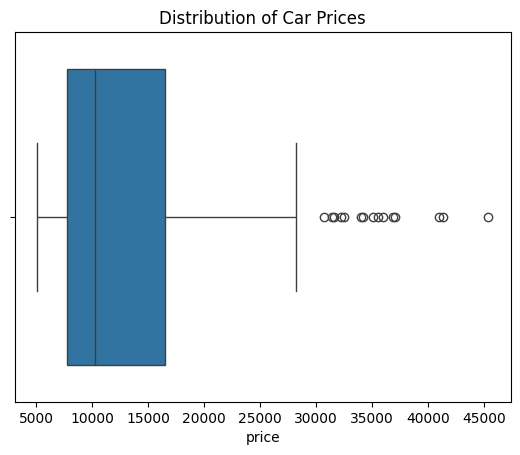

In [109]:
sns.boxplot(data=df_encoded,x='price')
plt.title('Distribution of Car Prices')
plt.show()

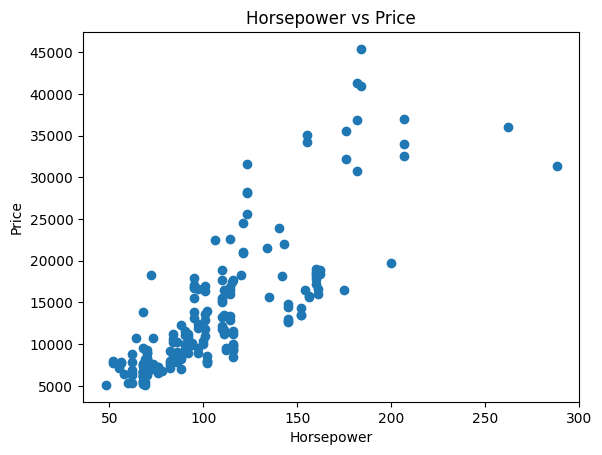

In [35]:
plt.scatter(data=df,x='horsepower',y='price')
plt.title("Horsepower vs Price")
plt.xlabel("Horsepower")
plt.ylabel("Price")
plt.show()

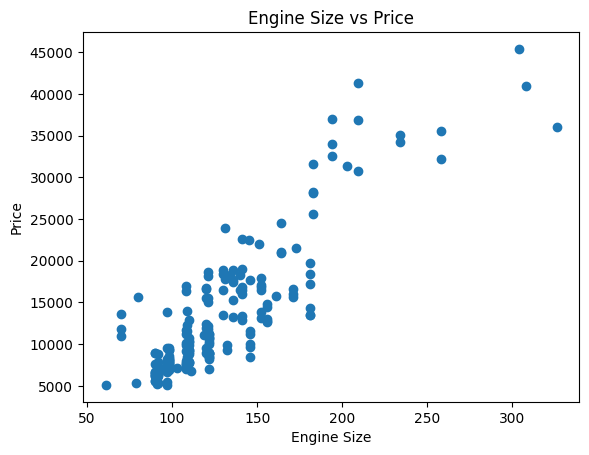

In [36]:
plt.scatter(data=df,x='enginesize',y='price')
plt.title("Engine Size vs Price")
plt.xlabel("Engine Size")
plt.ylabel("Price")
plt.show()

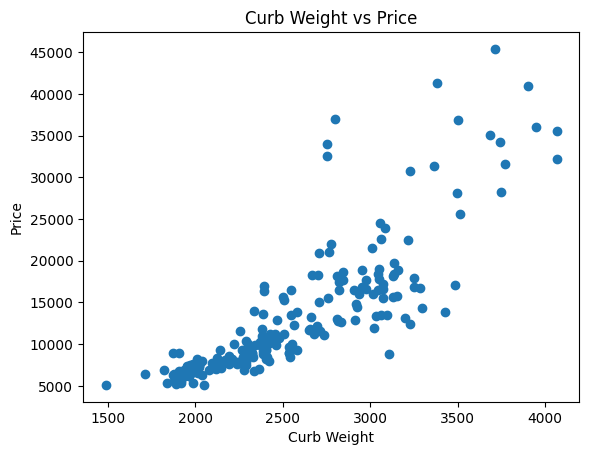

In [37]:
plt.scatter(data=df,x='curbweight',y='price')
plt.title("Curb Weight vs Price")
plt.xlabel("Curb Weight")
plt.ylabel("Price")
plt.show()

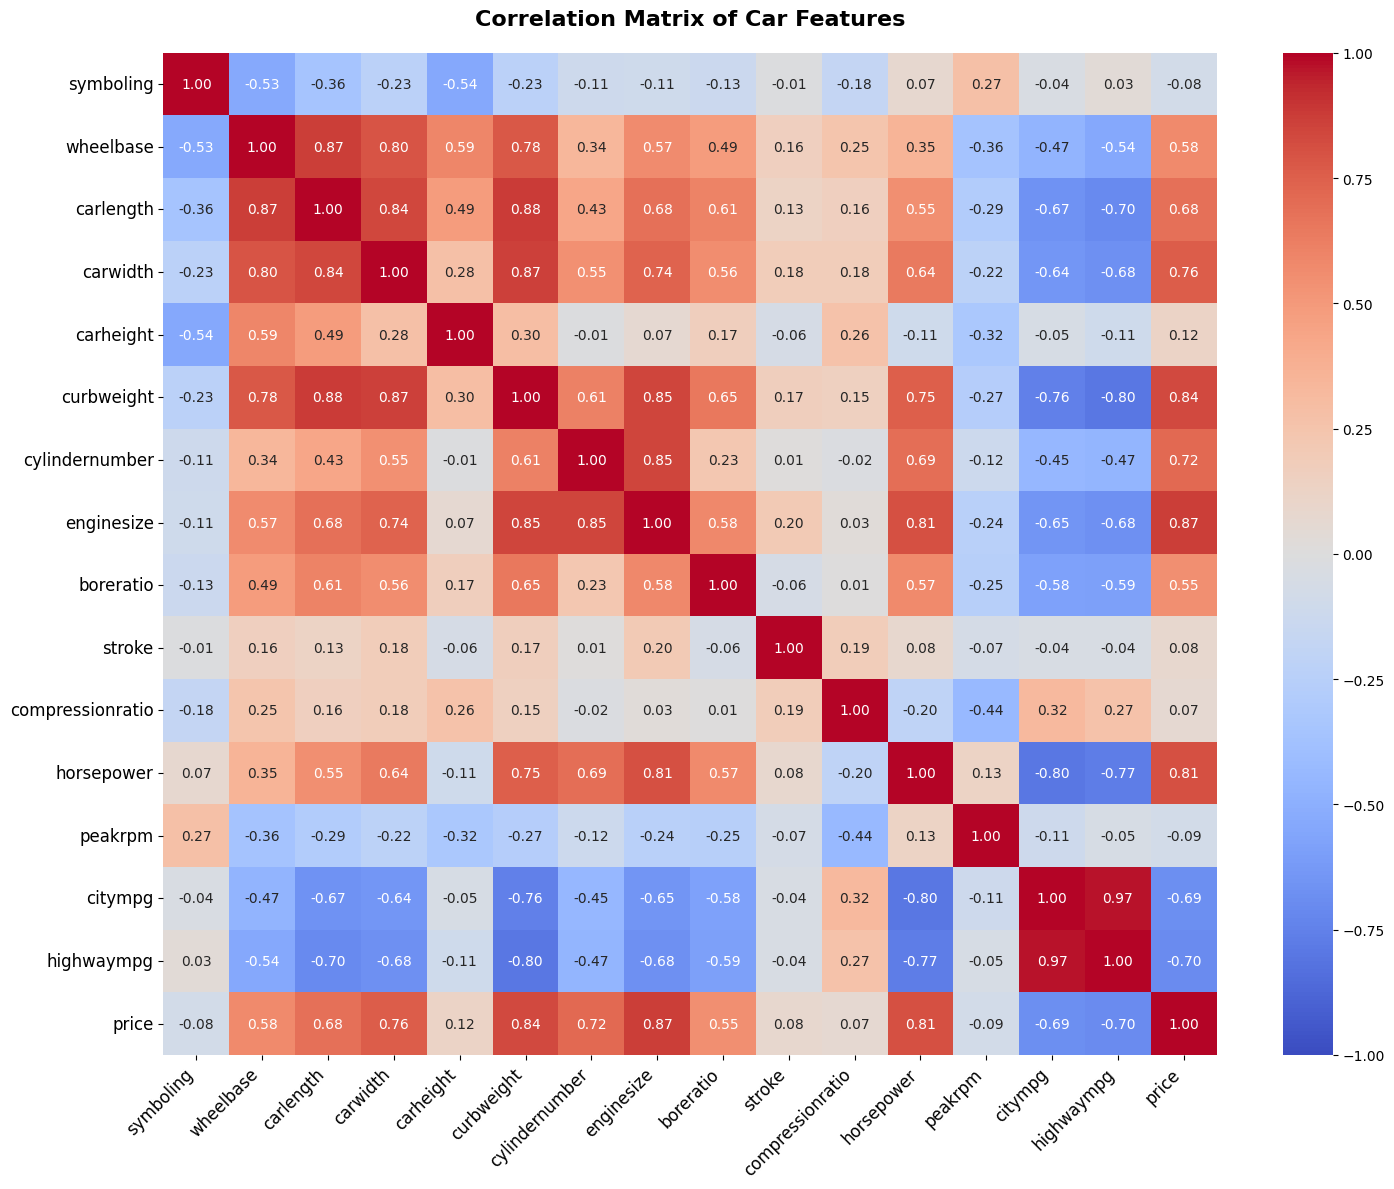

In [41]:
df_corr_numerical = df.select_dtypes(include=np.number).corr()
plt.figure(figsize=(15,12))
sns.heatmap(df_corr_numerical, annot=True,fmt='.2f',cmap='coolwarm',annot_kws={"size":10},vmin=-1,vmax=1,center=0)
plt.title("Correlation Matrix of Numerical Features", fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.title("Correlation Matrix of Car Features", fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

##Strong Relationship with Car Price:



*   wheelbase, carlength, carwidth, curbweight, cylindernumber, enginesize, boreratio, horsepower --> These all attributes have a Strong Relationship with Car Price.
*   carheight, stroke, compressionratio --> These have a Slightly positive relationship but it is lower than '0.5' which is negligible.
*   symbloing, peakrpm, citympg, highwaympg --> These all attributes have negative relationship with Car Price, so we can not cosider these.

##4. Build a Regression Model

In [88]:
from numpy.ma import count
numerical = df.select_dtypes(include=np.number)
# wheelbase, carlength, carwidth, curbweight, cylindernumber, enginesize, boreratio, horsepower
numerical
numerical_features = ['wheelbase', 'carlength', 'carwidth', 'curbweight', 'cylindernumber', 'enginesize', 'boreratio', 'horsepower']
categorical_features = [col for col in df_encoded.columns if '_' in col]

print(count(categorical_features))
print(count(numerical_features))

23
8


In [65]:
X = df_encoded[numerical_features + categorical_features]
y = df_encoded['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [99]:
X.columns

Index(['wheelbase', 'carlength', 'carwidth', 'curbweight', 'cylindernumber',
       'enginesize', 'boreratio', 'horsepower', 'fueltype_gas',
       'aspiration_turbo', 'carbody_hardtop', 'carbody_hatchback',
       'carbody_sedan', 'carbody_wagon', 'drivewheel_fwd', 'drivewheel_rwd',
       'enginetype_dohcv', 'enginetype_l', 'enginetype_ohc', 'enginetype_ohcf',
       'enginetype_ohcv', 'enginetype_rotor', 'enginelocation_rear',
       'doornumber_two', 'fuelsystem_2bbl', 'fuelsystem_4bbl',
       'fuelsystem_idi', 'fuelsystem_mfi', 'fuelsystem_mpfi',
       'fuelsystem_spdi', 'fuelsystem_spfi'],
      dtype='object')

In [69]:
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test_scaled[numerical_features] = scaler.transform(X_test[numerical_features])

In [71]:
model = LinearRegression()

model.fit(X_train_scaled, y_train)

LinearRegression()

In [97]:
X_test_scaled

,wheelbase,carlength,carwidth,curbweight,cylindernumber,enginesize,boreratio,horsepower,fueltype_gas,aspiration_turbo,...,enginetype_rotor,enginelocation_rear,doornumber_two,fuelsystem_2bbl,fuelsystem_4bbl,fuelsystem_idi,fuelsystem_mfi,fuelsystem_mpfi,fuelsystem_spdi,fuelsystem_spfi
15,0.801817,1.234887,0.461713,1.319744,1.453977,2.046956,1.112308,1.927399,1,0,...,0,0,0,0,0,0,0,1,0,0
9,0.129623,0.338150,0.934083,0.972939,0.550749,0.113653,-0.709646,1.378842,1,1,...,0,0,1,0,0,0,0,1,0,0
100,-0.256889,-0.060400,-0.341316,-0.498536,-0.352479,-0.158993,0.034009,-0.192025,1,0,...,0,0,0,1,0,0,0,0,0,0
132,0.062403,1.035612,0.272765,0.198994,-0.352479,-0.134207,0.814846,0.132122,1,0,...,0,0,1,0,0,0,0,1,0,0
68,1.894133,1.392647,2.067771,2.338608,0.550749,1.402522,0.963577,0.456269,0,1,...,0,0,0,0,0,1,0,0,0,0
95,-0.710620,-0.708044,-1.002634,-1.035399,-0.352479,-0.729070,-0.635281,-0.890189,1,0,...,0,0,1,1,0,0,0,0,0,0
159,-0.508962,-0.649922,-0.719212,-0.551439,-0.352479,-0.406852,-0.189088,-1.214336,0,0,...,0,0,0,0,0,1,0,0,0,0
162,-0.508962,-0.649922,-0.719212,-0.815951,-0.352479,-0.704284,-0.486550,-0.865254,1,0,...,0,0,0,1,0,0,0,0,0,0
147,-0.290499,-0.052097,-0.246842,-0.198755,-0.352479,-0.456424,1.112308,-0.266829,1,0,...,0,0,0,0,0,0,0,1,0,0
182,-0.240084,-0.201553,-0.199605,-0.578870,-0.352479,-0.729070,-1.155839,-1.314074,0,0,...,0,0,1,0,0,1,0,0,0,0


In [55]:
y_test

,price
15,30760.000
9,17859.167
100,9549.000
132,11850.000
68,28248.000
95,7799.000
159,7788.000
162,9258.000
147,10198.000
182,7775.000


In [75]:
y_pred = model.predict(X_test_scaled)
y_pred

array([23844.37664342, 19150.25803917, 10175.54588626, 11289.6762548 ,
       26210.47886832,  5770.53090555,  6217.68053675,  7992.83946882,
        7735.17597928,  8336.08432958, 15748.86361007,  8226.9444939 ,
       16036.4876042 , 11963.21706772, 38651.39228016,  5868.8660333 ,
       -6683.6900633 , 13722.96652232, 10870.60869536,  9402.47486584,
       12017.96327441, 17763.31242918,  6632.68909756,  5000.28838106,
        6867.18164345, 25328.2805    , 14164.1321624 , 15824.99351857,
        4592.31389045, 17352.4091065 , 27257.61113131,  5531.5591818 ,
        6382.85861652, 21828.90248578,  6636.60273569, 26375.89528211,
       12607.97244881, 12734.37426272,  6407.97592004, 14096.67435393,
        6831.69825307])

Before Scaling

Mean Absolute Error: 2455.6502324475355

Mean Squared Error: 14846942.918160262

Root Mean Squared Error: 3853.173097352397

R-squared: 0.8119307484883124

##5. Evaluate the Model

In [76]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R-squared:", r2)

Mean Absolute Error: 2455.650232447532
Mean Squared Error: 14846942.918160237
Root Mean Squared Error: 3853.1730973523936
R-squared: 0.8119307484883127


In [84]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

coefficients

,Feature,Coefficient
0,wheelbase,1062.031854
1,carlength,-597.659536
2,carwidth,1905.699504
3,curbweight,2169.232772
4,cylindernumber,808.698938
5,enginesize,2672.528941
6,boreratio,-580.096844
7,horsepower,-440.718789
8,fueltype_gas,1211.038605
9,aspiration_turbo,2010.590363


##6. Visualization of Predictions

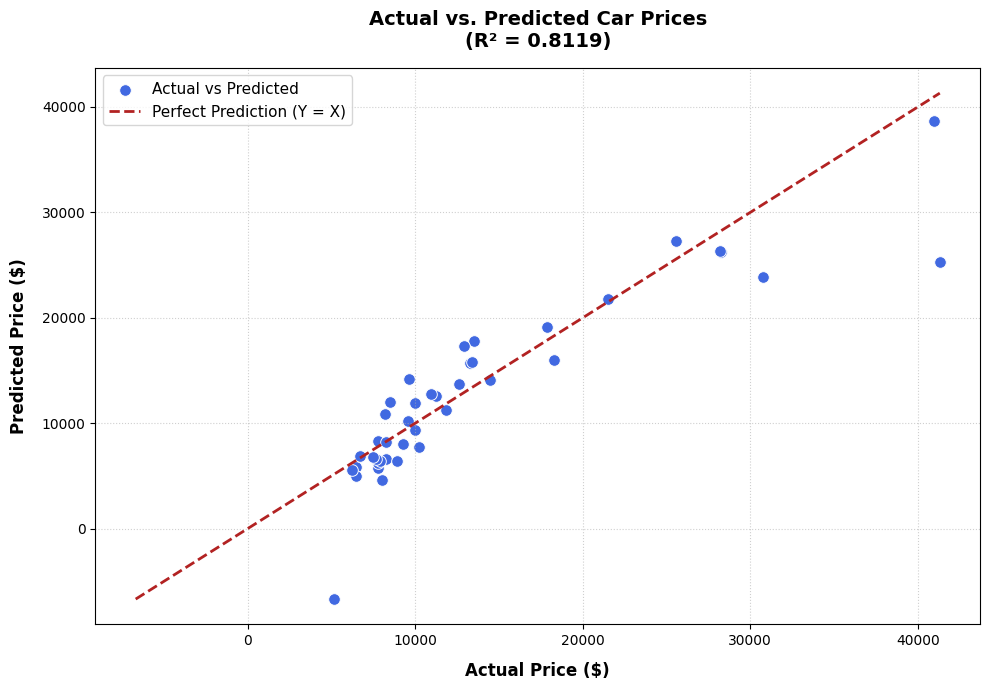

In [94]:
plt.figure(figsize=(10, 7))

sns.scatterplot(x=y_test, y=y_pred, color='royalblue', label='Actual vs Predicted', edgecolor='w', s=70)

max_val = max(y_test.max(), y_pred.max())
min_val = min(y_test.min(), y_pred.min())

plt.plot([min_val, max_val],[min_val, max_val],color='firebrick',linestyle='--', linewidth=2, label='Perfect Prediction (Y = X)')

plt.xlabel('Actual Price ($)', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Predicted Price ($)', fontsize=12, fontweight='bold', labelpad=10)
plt.title('Actual vs. Predicted Car Prices\n(R² = 0.8119)', fontsize=14, fontweight='bold', pad=15)

plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper left', fontsize=11)
plt.tight_layout()
plt.show()

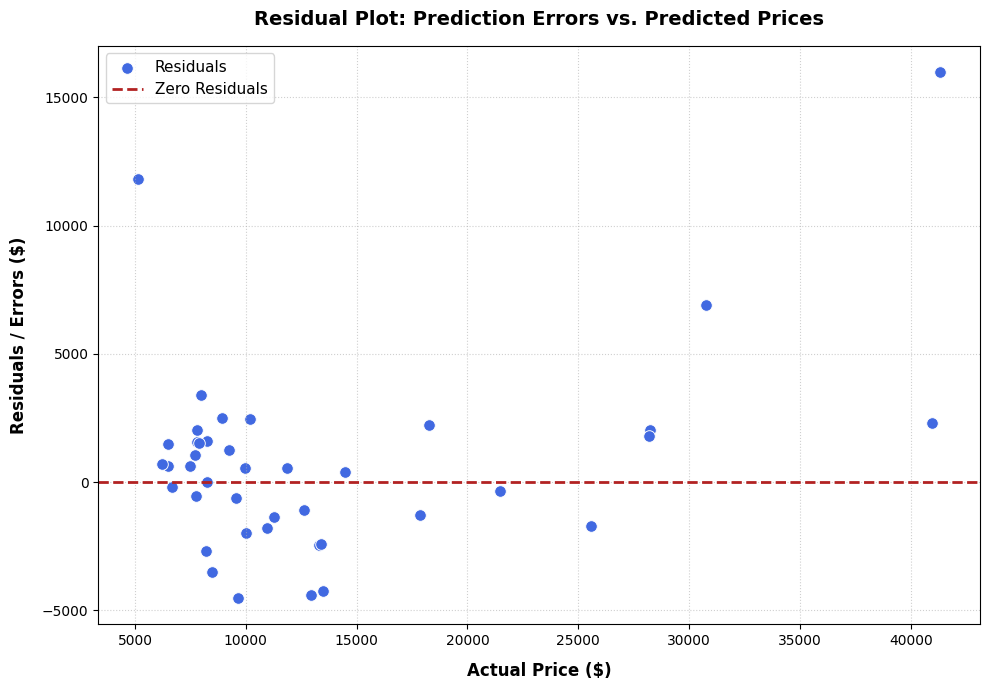

In [95]:
residual = y_test - y_pred

plt.figure(figsize=(10,7))

sns.scatterplot(x=y_test, y=residual, color='royalblue', label='Residuals', edgecolor='w', s=70)
plt.axhline(y=0, color='firebrick', linestyle='--', linewidth=2, label='Zero Residuals')

plt.xlabel('Actual Price ($)', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Residuals / Errors ($)', fontsize=12, fontweight='bold', labelpad=10)
plt.title('Residual Plot: Prediction Errors vs. Predicted Prices', fontsize=14, fontweight='bold', pad=15)

plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper left', fontsize=11)
plt.tight_layout()
plt.show()

*   R^2(81.19%) : This Multiple Linear Regression model explains 81.19% of the total variance in car prices. In the context of the American automotive market dataset, an \[R^{2}\] score over 80% represents a highly successful and robust linear baseline. This proves that structural and mechanical indicators—like engine size, horse power, and wheel drive placement—share an intrinsically strong linear relationship with a vehicle's baseline market value.

*   Mean Absolute Error ($2,455.65): The Mean Absolute Error measures the average absolute size of your errors without considering direction. On average, your model's price estimates deviate from the actual sticker prices by roughly $2,456.Given that the vast majority in consumer cars in this dataset falls in the range of $5,000 to $18,000 range, your model maintains a reasonable, real-world baseline accuracy of approximately 15% to 18% error across the standard consumer segment.

*   Root Mean Squared Error ($3,853.17): The Root Mean Squared Error is significantly higher than the MAE ($3,853 vs $2,455). Because RMSE squares errors before averaging them, it is heavily penalised by a few extreme outliers. This large discrepancy indicates that the model is making very large errors on a small group of cars.

##7. Prediction of a New Car

In [106]:
sample_car_data = {
    'wheelbase': [96.5],
    'carlength': [173.5],
    'carwidth': [65.5],
    'curbweight':2200,
    'cylindernumber':4,
    'enginesize':110,
    'boreratio': [3.15],
    'horsepower':90,
    'fueltype_gas':1,
    'aspiration_turbo':0,
    'carbody_hardtop':0,
    'carbody_hatchback':0,
    'carbody_sedan':1,
    'carbody_wagon':0,
    'drivewheel_fwd':1,
    'drivewheel_rwd':0,
    'enginetype_dohcv':0,
    'enginetype_l':0,
    'enginetype_ohc':1,
    'enginetype_ohcf':0,
    'enginetype_ohcv':0,
    'enginetype_rotor':0,
    'enginelocation_rear':1,
    'enginelocation_front':0,
    'doornumber_four':0,
    'doornumber_two':1,
    'fuelsystem_2bbl':0,
    'fuelsystem_4bbl':0,
    'fuelsystem_idi':0,
    'fuelsystem_mfi':1,
    'fuelsystem_mpfi':0,
    'fuelsystem_spdi':0,
    'fuelsystem_spfi': [0]
}

sample_df = pd.DataFrame(sample_car_data)

feature_order = [
    'wheelbase', 'carlength', 'carwidth', 'curbweight', 'cylindernumber',
    'enginesize', 'boreratio', 'horsepower', 'fueltype_gas',
    'aspiration_turbo', 'carbody_hardtop', 'carbody_hatchback',
    'carbody_sedan', 'carbody_wagon', 'drivewheel_fwd', 'drivewheel_rwd',
    'enginetype_dohcv', 'enginetype_l', 'enginetype_ohc', 'enginetype_ohcf',
    'enginetype_ohcv', 'enginetype_rotor', 'enginelocation_rear',
    'doornumber_two', 'fuelsystem_2bbl', 'fuelsystem_4bbl',
    'fuelsystem_idi', 'fuelsystem_mfi', 'fuelsystem_mpfi',
    'fuelsystem_spdi', 'fuelsystem_spfi'
]

sample_df = sample_df[feature_order]

sample_df

,wheelbase,carlength,carwidth,curbweight,cylindernumber,enginesize,boreratio,horsepower,fueltype_gas,aspiration_turbo,...,enginetype_rotor,enginelocation_rear,doornumber_two,fuelsystem_2bbl,fuelsystem_4bbl,fuelsystem_idi,fuelsystem_mfi,fuelsystem_mpfi,fuelsystem_spdi,fuelsystem_spfi
0,96.5,173.5,65.5,2200,4,110,3.15,90,1,0,...,0,1,1,0,0,0,1,0,0,0


In [108]:
sample_df_scaled = sample_df.copy()

sample_df_scaled[numerical_features] = scaler.transform(sample_df[numerical_features])

sample_predict = model.predict(sample_df_scaled)

print("Approximate Selling Price:", sample_predict[0])

Approximate Selling Price: 24066.719626793125
